## metriche - generic_4 metrix

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

log_text = """
python3 -m dqn.generic_4_metrix
[Ep     0] ε=1.000 |     R: 7126.6 (avg 7126.6) | Survived:  0.5s (avg_score  0.5s) | Ev/step: 2.23 | MaxEv:  3 | Q(avg):   0.04 | Q(ch):   0.00
[Ep    50] ε=0.975 |     R: 1015.8 (avg 1233.8) | Survived:  0.4s (avg_score  1.0s) | Ev/step: 1.62 | MaxEv:  3 | Q(avg): 152.99 | Q(ch): 160.95
[Ep   100] ε=0.951 |     R:  756.8 (avg 1156.2) | Survived:  1.2s (avg_score  1.0s) | Ev/step: 2.09 | MaxEv:  4 | Q(avg): 295.05 | Q(ch): 351.37
[Ep   150] ε=0.927 |     R:  733.7 (avg  831.5) | Survived:  1.1s (avg_score  1.0s) | Ev/step: 2.29 | MaxEv:  4 | Q(avg): 408.35 | Q(ch): 461.64
[Ep   200] ε=0.904 |     R:  337.3 (avg  783.4) | Survived:  0.5s (avg_score  1.0s) | Ev/step: 2.32 | MaxEv:  4 | Q(avg): 503.97 | Q(ch): 755.44
[Ep   250] ε=0.882 |     R:  436.7 (avg  707.5) | Survived:  0.3s (avg_score  1.0s) | Ev/step: 2.33 | MaxEv:  4 | Q(avg): 543.42 | Q(ch): 570.77
[Ep   300] ε=0.860 |     R:  268.5 (avg  741.7) | Survived:  0.4s (avg_score  0.9s) | Ev/step: 2.32 | MaxEv:  4 | Q(avg): 449.02 | Q(ch): 172.12
[Ep   350] ε=0.839 |     R:  935.8 (avg  595.2) | Survived:  1.2s (avg_score  0.9s) | Ev/step: 3.12 | MaxEv:  6 | Q(avg): 851.58 | Q(ch): 852.34
[Ep   400] ε=0.818 |     R:  648.2 (avg  703.5) | Survived:  1.1s (avg_score  1.0s) | Ev/step: 2.45 | MaxEv:  4 | Q(avg): 391.24 | Q(ch): 474.41
[Ep   450] ε=0.798 |     R:  624.3 (avg  631.5) | Survived:  1.1s (avg_score  0.9s) | Ev/step: 2.28 | MaxEv:  4 | Q(avg): 364.73 | Q(ch): 375.40
[Ep   500] ε=0.778 |     R:  563.6 (avg  638.6) | Survived:  1.1s (avg_score  0.9s) | Ev/step: 2.13 | MaxEv:  4 | Q(avg): 419.72 | Q(ch): 445.11
[Ep   550] ε=0.759 |     R: 1217.5 (avg  727.7) | Survived:  2.0s (avg_score  1.0s) | Ev/step: 2.32 | MaxEv:  6 | Q(avg): 674.32 | Q(ch): 730.11
[Ep   600] ε=0.740 |     R:  249.2 (avg  644.9) | Survived:  0.5s (avg_score  0.9s) | Ev/step: 2.21 | MaxEv:  3 | Q(avg): 455.82 | Q(ch): 492.74
[Ep   650] ε=0.722 |     R:  822.7 (avg  706.3) | Survived:  1.2s (avg_score  1.1s) | Ev/step: 1.83 | MaxEv:  3 | Q(avg): 416.01 | Q(ch): 341.58
[Ep   700] ε=0.704 |     R:  344.5 (avg  670.2) | Survived:  0.4s (avg_score  0.9s) | Ev/step: 2.35 | MaxEv:  4 | Q(avg): 445.90 | Q(ch): 406.58
[Ep   750] ε=0.687 |     R:  663.4 (avg  725.6) | Survived:  1.2s (avg_score  1.0s) | Ev/step: 1.61 | MaxEv:  4 | Q(avg): 413.77 | Q(ch): 343.91
[Ep   800] ε=0.670 |     R:  668.9 (avg  667.2) | Survived:  1.2s (avg_score  1.0s) | Ev/step: 1.70 | MaxEv:  4 | Q(avg): 380.69 | Q(ch): 399.48
[Ep   850] ε=0.653 |     R:  742.0 (avg  644.3) | Survived:  1.2s (avg_score  1.1s) | Ev/step: 2.05 | MaxEv:  4 | Q(avg): 452.94 | Q(ch): 449.14
[Ep   900] ε=0.637 |     R:  566.0 (avg  564.0) | Survived:  1.2s (avg_score  1.0s) | Ev/step: 1.53 | MaxEv:  3 | Q(avg): 423.42 | Q(ch): 379.64
[Ep   950] ε=0.622 |     R:  266.3 (avg  648.9) | Survived:  0.5s (avg_score  1.3s) | Ev/step: 2.33 | MaxEv:  4 | Q(avg): 494.60 | Q(ch): 528.27
[Ep  1000] ε=0.606 |     R:  689.7 (avg  612.0) | Survived:  1.3s (avg_score  1.2s) | Ev/step: 1.73 | MaxEv:  3 | Q(avg): 388.25 | Q(ch): 407.13
[Ep  1050] ε=0.591 |     R:  837.5 (avg  626.0) | Survived:  1.2s (avg_score  1.2s) | Ev/step: 3.46 | MaxEv:  6 | Q(avg): 685.86 | Q(ch): 686.21
[Ep  1100] ε=0.577 |     R:  607.4 (avg  668.4) | Survived:  1.1s (avg_score  1.3s) | Ev/step: 1.88 | MaxEv:  4 | Q(avg): 495.90 | Q(ch): 468.90
[Ep  1150] ε=0.562 |     R:  809.9 (avg  830.0) | Survived:  1.1s (avg_score  1.6s) | Ev/step: 3.34 | MaxEv:  6 | Q(avg): 701.23 | Q(ch): 683.65
[Ep  1200] ε=0.548 |     R:  692.1 (avg  906.6) | Survived:  1.1s (avg_score  1.6s) | Ev/step: 2.24 | MaxEv:  4 | Q(avg): 662.02 | Q(ch): 666.45
[Ep  1250] ε=0.535 |     R:  804.3 (avg  964.8) | Survived:  1.3s (avg_score  1.6s) | Ev/step: 3.00 | MaxEv:  6 | Q(avg): 708.84 | Q(ch): 720.93
[Ep  1300] ε=0.522 |     R:  233.0 (avg 1126.7) | Survived:  0.3s (avg_score  1.8s) | Ev/step: 2.00 | MaxEv:  3 | Q(avg): 535.80 | Q(ch): 492.21
[Ep  1350] ε=0.509 |     R: 3149.6 (avg 1454.3) | Survived:  4.2s (avg_score  2.2s) | Ev/step: 1.64 | MaxEv:  4 | Q(avg): 539.67 | Q(ch): 546.93
[Ep  1400] ε=0.496 |     R:  232.0 (avg 1219.5) | Survived:  0.5s (avg_score  1.9s) | Ev/step: 1.71 | MaxEv:  3 | Q(avg): 549.45 | Q(ch): 485.73
[Ep  1450] ε=0.484 |     R: 7008.4 (avg 3430.1) | Survived: 10.1s (avg_score  4.8s) | Ev/step: 3.34 | MaxEv:  8 | Q(avg): 723.86 | Q(ch): 729.86
[Ep  1500] ε=0.472 |     R: 7598.5 (avg 2923.5) | Survived: 10.3s (avg_score  4.2s) | Ev/step: 3.79 | MaxEv:  8 | Q(avg): 736.28 | Q(ch): 734.65
[Ep  1550] ε=0.460 |     R:  838.3 (avg 2166.1) | Survived:  1.2s (avg_score  3.1s) | Ev/step: 3.10 | MaxEv:  6 | Q(avg): 741.62 | Q(ch): 832.43
[Ep  1600] ε=0.449 |     R: 3300.4 (avg 3100.2) | Survived:  4.6s (avg_score  4.6s) | Ev/step: 3.22 | MaxEv:  8 | Q(avg): 724.83 | Q(ch): 739.27
[Ep  1650] ε=0.438 |     R: 4975.2 (avg 2673.4) | Survived:  8.4s (avg_score  4.0s) | Ev/step: 2.46 | MaxEv:  6 | Q(avg): 619.25 | Q(ch): 632.70
[Ep  1700] ε=0.427 |     R:  803.6 (avg 3677.9) | Survived:  1.2s (avg_score  5.6s) | Ev/step: 1.57 | MaxEv:  3 | Q(avg): 486.17 | Q(ch): 505.84
[Ep  1750] ε=0.417 |     R: 4231.8 (avg 2345.2) | Survived:  6.8s (avg_score  3.7s) | Ev/step: 3.05 | MaxEv:  7 | Q(avg): 737.51 | Q(ch): 748.44
[Ep  1800] ε=0.406 |     R:  628.9 (avg 2971.7) | Survived:  1.2s (avg_score  4.5s) | Ev/step: 1.66 | MaxEv:  4 | Q(avg): 498.79 | Q(ch): 516.06
[Ep  1850] ε=0.396 |     R: 1954.3 (avg 2769.2) | Survived:  4.2s (avg_score  4.2s) | Ev/step: 1.60 | MaxEv:  4 | Q(avg): 642.58 | Q(ch): 634.95
[Ep  1900] ε=0.386 |     R: 2631.3 (avg 2522.1) | Survived:  3.4s (avg_score  3.6s) | Ev/step: 3.86 | MaxEv:  8 | Q(avg): 821.00 | Q(ch): 829.52
[Ep  1950] ε=0.377 |     R: 1675.8 (avg 3235.7) | Survived:  2.7s (avg_score  4.6s) | Ev/step: 1.96 | MaxEv:  5 | Q(avg): 689.96 | Q(ch): 699.95
[Ep  2000] ε=0.368 |     R: 2118.4 (avg 2615.2) | Survived:  3.1s (avg_score  3.7s) | Ev/step: 3.47 | MaxEv:  8 | Q(avg): 795.36 | Q(ch): 788.92
[Ep  2050] ε=0.359 |     R:  598.1 (avg 2414.9) | Survived:  1.2s (avg_score  3.4s) | Ev/step: 1.90 | MaxEv:  4 | Q(avg): 530.47 | Q(ch): 556.33
[Ep  2100] ε=0.350 |     R:  552.8 (avg 3531.3) | Survived:  1.1s (avg_score  4.8s) | Ev/step: 1.82 | MaxEv:  4 | Q(avg): 510.45 | Q(ch): 504.59
[Ep  2150] ε=0.341 |     R: 1821.0 (avg 2906.8) | Survived:  2.9s (avg_score  4.0s) | Ev/step: 2.94 | MaxEv:  6 | Q(avg): 780.64 | Q(ch): 785.69
[Ep  2200] ε=0.333 |     R: 1683.5 (avg 3902.0) | Survived:  2.7s (avg_score  5.2s) | Ev/step: 3.08 | MaxEv:  6 | Q(avg): 771.49 | Q(ch): 756.66
[Ep  2250] ε=0.324 |     R:  685.9 (avg 3626.9) | Survived:  0.5s (avg_score  4.9s) | Ev/step: 2.24 | MaxEv:  4 | Q(avg): 644.50 | Q(ch): 684.93
[Ep  2300] ε=0.316 |     R:  648.5 (avg 5888.4) | Survived:  1.1s (avg_score  7.6s) | Ev/step: 2.24 | MaxEv:  4 | Q(avg): 417.04 | Q(ch): 417.03
[Ep  2350] ε=0.309 |     R: 3154.6 (avg 5077.2) | Survived:  3.9s (avg_score  6.6s) | Ev/step: 3.32 | MaxEv:  8 | Q(avg): 835.33 | Q(ch): 834.26
[Ep  2400] ε=0.301 |     R: 4682.1 (avg 7291.1) | Survived:  6.2s (avg_score  9.4s) | Ev/step: 3.33 | MaxEv:  7 | Q(avg): 840.70 | Q(ch): 849.32
[Ep  2450] ε=0.294 |     R:  686.3 (avg 7851.5) | Survived:  1.1s (avg_score 10.2s) | Ev/step: 2.19 | MaxEv:  4 | Q(avg): 600.66 | Q(ch): 636.28
[Ep  2500] ε=0.286 |     R: 5058.1 (avg 11045.5) | Survived:  6.9s (avg_score 14.1s) | Ev/step: 3.62 | MaxEv:  8 | Q(avg): 933.66 | Q(ch): 937.33
[Ep  2550] ε=0.279 |     R: 2500.3 (avg 14562.2) | Survived:  3.6s (avg_score 18.1s) | Ev/step: 2.88 | MaxEv:  6 | Q(avg): 815.61 | Q(ch): 828.95
[Ep  2600] ε=0.272 |     R: 9330.8 (avg 12211.7) | Survived: 11.3s (avg_score 15.3s) | Ev/step: 4.44 | MaxEv:  9 | Q(avg): 1061.56 | Q(ch): 1067.34
[Ep  2650] ε=0.266 |     R: 32425.4 (avg 10048.3) | Survived: 42.5s (avg_score 12.8s) | Ev/step: 3.53 | MaxEv:  8 | Q(avg): 1012.63 | Q(ch): 1020.38
[Ep  2700] ε=0.259 |     R: 10534.7 (avg 9276.7) | Survived: 13.6s (avg_score 12.1s) | Ev/step: 3.80 | MaxEv:  8 | Q(avg): 989.28 | Q(ch): 996.55
[Ep  2750] ε=0.253 |     R: 8083.6 (avg 10623.8) | Survived:  9.6s (avg_score 13.4s) | Ev/step: 4.49 | MaxEv:  8 | Q(avg): 1078.46 | Q(ch): 1088.39
[Ep  2800] ε=0.246 |     R:  703.6 (avg 12332.6) | Survived:  1.1s (avg_score 16.2s) | Ev/step: 2.19 | MaxEv:  4 | Q(avg): 683.84 | Q(ch): 751.68
[Ep  2850] ε=0.240 |     R: 15993.1 (avg 11734.3) | Survived: 19.9s (avg_score 15.9s) | Ev/step: 4.34 | MaxEv:  8 | Q(avg): 1054.66 | Q(ch): 1058.69
[Ep  2900] ε=0.234 |     R: 3999.9 (avg 14637.0) | Survived:  7.0s (avg_score 19.5s) | Ev/step: 2.72 | MaxEv:  6 | Q(avg): 999.90 | Q(ch): 1007.53
[Ep  2950] ε=0.229 |     R: 5668.2 (avg 15684.9) | Survived:  8.1s (avg_score 20.7s) | Ev/step: 3.86 | MaxEv:  8 | Q(avg): 1034.27 | Q(ch): 1046.76
[Ep  3000] ε=0.223 |     R: 23419.7 (avg 14017.4) | Survived: 31.6s (avg_score 18.6s) | Ev/step: 4.14 | MaxEv:  9 | Q(avg): 1065.52 | Q(ch): 1072.40
[Ep  3050] ε=0.217 |     R: 1908.7 (avg 13674.0) | Survived:  2.8s (avg_score 18.3s) | Ev/step: 2.00 | MaxEv:  5 | Q(avg): 994.50 | Q(ch): 1025.82
[Ep  3100] ε=0.212 |     R: 2553.7 (avg 11569.1) | Survived:  4.3s (avg_score 15.4s) | Ev/step: 2.76 | MaxEv:  6 | Q(avg): 986.73 | Q(ch): 1001.55
[Ep  3150] ε=0.207 |     R: 9651.2 (avg 14503.8) | Survived: 12.9s (avg_score 18.7s) | Ev/step: 3.11 | MaxEv:  8 | Q(avg): 1025.24 | Q(ch): 1037.64
[Ep  3200] ε=0.202 |     R: 11062.9 (avg 15402.8) | Survived: 13.3s (avg_score 19.9s) | Ev/step: 4.40 | MaxEv:  8 | Q(avg): 1096.75 | Q(ch): 1104.61
[Ep  3250] ε=0.197 |     R: 22356.4 (avg 12232.6) | Survived: 27.9s (avg_score 15.8s) | Ev/step: 4.07 | MaxEv:  8 | Q(avg): 1087.07 | Q(ch): 1095.45
[Ep  3300] ε=0.192 |     R: 48224.1 (avg 13633.2) | Survived: 60.0s (avg_score 17.5s) | Ev/step: 3.88 | MaxEv:  8 | Q(avg): 1123.25 | Q(ch): 1127.08
[Ep  3350] ε=0.187 |     R:  925.0 (avg 16707.5) | Survived:  1.1s (avg_score 21.0s) | Ev/step: 3.38 | MaxEv:  6 | Q(avg): 1014.56 | Q(ch): 1058.14
[Ep  3400] ε=0.183 |     R: 16337.1 (avg 11683.1) | Survived: 21.5s (avg_score 14.7s) | Ev/step: 4.02 | MaxEv:  8 | Q(avg): 1087.88 | Q(ch): 1096.74
[Ep  3450] ε=0.178 |     R: 1245.9 (avg 8695.3) | Survived:  1.1s (avg_score 11.1s) | Ev/step: 3.56 | MaxEv:  6 | Q(avg): 797.76 | Q(ch): 861.59
[Ep  3500] ε=0.174 |     R: 10284.1 (avg 12780.9) | Survived: 13.2s (avg_score 16.1s) | Ev/step: 3.68 | MaxEv:  8 | Q(avg): 1104.22 | Q(ch): 1112.28
[Ep  3550] ε=0.169 |     R: 4594.7 (avg 14061.9) | Survived:  6.5s (avg_score 17.8s) | Ev/step: 3.27 | MaxEv:  8 | Q(avg): 1083.04 | Q(ch): 1101.01
[Ep  3600] ε=0.165 |     R: 46322.4 (avg 15171.1) | Survived: 60.0s (avg_score 19.6s) | Ev/step: 4.15 | MaxEv:  9 | Q(avg): 1181.08 | Q(ch): 1184.47
[Ep  3650] ε=0.161 |     R: 21246.1 (avg 14114.3) | Survived: 30.7s (avg_score 18.7s) | Ev/step: 3.60 | MaxEv:  8 | Q(avg): 1130.52 | Q(ch): 1137.25
[Ep  3700] ε=0.157 |     R: 14011.6 (avg 16709.6) | Survived: 18.1s (avg_score 21.5s) | Ev/step: 3.92 | MaxEv:  8 | Q(avg): 1134.82 | Q(ch): 1139.66
[Ep  3750] ε=0.153 |     R: 36560.2 (avg 15605.0) | Survived: 47.1s (avg_score 20.1s) | Ev/step: 4.23 | MaxEv:  8 | Q(avg): 1173.23 | Q(ch): 1179.80
[Ep  3800] ε=0.149 |     R: 16892.5 (avg 18461.4) | Survived: 19.5s (avg_score 23.3s) | Ev/step: 4.38 | MaxEv:  9 | Q(avg): 1180.91 | Q(ch): 1187.85
[Ep  3850] ε=0.146 |     R: 4224.5 (avg 17514.6) | Survived:  5.0s (avg_score 22.2s) | Ev/step: 3.69 | MaxEv:  8 | Q(avg): 1122.62 | Q(ch): 1133.53
[Ep  3900] ε=0.142 |     R: 11398.4 (avg 22554.6) | Survived: 13.0s (avg_score 27.8s) | Ev/step: 4.09 | MaxEv:  8 | Q(avg): 1152.45 | Q(ch): 1169.65
[Ep  3950] ε=0.139 |     R: 47801.1 (avg 21879.5) | Survived: 60.0s (avg_score 27.4s) | Ev/step: 4.35 | MaxEv:  9 | Q(avg): 1212.85 | Q(ch): 1217.96
[Ep  4000] ε=0.135 |     R: 3064.2 (avg 16764.3) | Survived:  3.9s (avg_score 20.8s) | Ev/step: 3.59 | MaxEv:  8 | Q(avg): 1091.13 | Q(ch): 1109.25
[Ep  4050] ε=0.132 |     R: 50654.5 (avg 14318.6) | Survived: 60.0s (avg_score 17.4s) | Ev/step: 4.71 | MaxEv:  8 | Q(avg): 1251.31 | Q(ch): 1255.04
[Ep  4100] ε=0.129 |     R: 52107.8 (avg 17446.0) | Survived: 60.0s (avg_score 21.3s) | Ev/step: 4.64 | MaxEv:  8 | Q(avg): 1242.37 | Q(ch): 1247.21
[Ep  4150] ε=0.125 |     R:  818.9 (avg 18243.8) | Survived:  1.1s (avg_score 21.6s) | Ev/step: 3.45 | MaxEv:  5 | Q(avg): 912.76 | Q(ch): 961.61
[Ep  4200] ε=0.122 |     R: 36734.5 (avg 19066.9) | Survived: 43.1s (avg_score 22.8s) | Ev/step: 4.53 | MaxEv:  8 | Q(avg): 1242.09 | Q(ch): 1250.86
[Ep  4250] ε=0.119 |     R: 14495.6 (avg 21771.3) | Survived: 15.8s (avg_score 26.1s) | Ev/step: 4.56 | MaxEv:  8 | Q(avg): 1262.13 | Q(ch): 1269.70
[Ep  4300] ε=0.116 |     R: 50295.1 (avg 14430.2) | Survived: 60.0s (avg_score 17.4s) | Ev/step: 4.51 | MaxEv:  9 | Q(avg): 1249.98 | Q(ch): 1255.10
[Ep  4350] ε=0.113 |     R: 43223.1 (avg 17855.9) | Survived: 49.4s (avg_score 21.0s) | Ev/step: 4.75 | MaxEv:  9 | Q(avg): 1271.10 | Q(ch): 1276.13
[Ep  4400] ε=0.111 |     R: 51755.9 (avg 14757.9) | Survived: 60.0s (avg_score 17.3s) | Ev/step: 4.67 | MaxEv:  8 | Q(avg): 1287.76 | Q(ch): 1292.78
[Ep  4450] ε=0.108 |     R: 50742.2 (avg 20249.5) | Survived: 60.0s (avg_score 23.0s) | Ev/step: 4.61 | MaxEv:  8 | Q(avg): 1250.54 | Q(ch): 1257.47
[Ep  4500] ε=0.105 |     R:  990.2 (avg 26095.7) | Survived:  1.2s (avg_score 29.1s) | Ev/step: 3.49 | MaxEv:  5 | Q(avg): 638.24 | Q(ch): 686.80
[Ep  4550] ε=0.103 |     R: 22198.4 (avg 26568.4) | Survived: 20.8s (avg_score 28.9s) | Ev/step: 4.11 | MaxEv:  8 | Q(avg): 1243.56 | Q(ch): 1252.78
[Ep  4600] ε=0.100 |     R: 1077.7 (avg 19999.7) | Survived:  1.3s (avg_score 20.4s) | Ev/step: 3.23 | MaxEv:  6 | Q(avg): 710.28 | Q(ch): 782.60
[Ep  4650] ε=0.098 |     R: 13079.3 (avg 18810.6) | Survived: 10.8s (avg_score 18.2s) | Ev/step: 4.12 | MaxEv:  9 | Q(avg): 1259.98 | Q(ch): 1272.76
[Ep  4700] ε=0.095 |     R: 36569.1 (avg 17505.7) | Survived: 28.5s (avg_score 16.2s) | Ev/step: 3.77 | MaxEv:  8 | Q(avg): 1289.40 | Q(ch): 1302.13
[Ep  4750] ε=0.093 |     R: 19377.4 (avg 32495.3) | Survived: 13.9s (avg_score 28.3s) | Ev/step: 3.33 | MaxEv:  8 | Q(avg): 1334.33 | Q(ch): 1350.61
[Ep  4800] ε=0.091 |     R: 65467.5 (avg 23173.0) | Survived: 60.0s (avg_score 21.6s) | Ev/step: 4.21 | MaxEv:  8 | Q(avg): 1333.85 | Q(ch): 1342.07
[Ep  4850] ε=0.088 |     R: 106864.3 (avg 27547.5) | Survived: 60.0s (avg_score 20.9s) | Ev/step: 3.97 | MaxEv:  8 | Q(avg): 1363.13 | Q(ch): 1373.24
[Ep  4900] ε=0.086 |     R: 41483.3 (avg 22222.8) | Survived: 54.5s (avg_score 25.0s) | Ev/step: 4.09 | MaxEv:  9 | Q(avg): 1372.17 | Q(ch): 1380.48
[Ep  4950] ε=0.084 |     R: 45716.9 (avg 15484.7) | Survived: 60.0s (avg_score 20.0s) | Ev/step: 4.31 | MaxEv:  9 | Q(avg): 1367.48 | Q(ch): 1374.54

"""


In [2]:
pattern = re.compile(
    r"\[Ep\s+(\d+)\].*?"
    r"ε=([\d\.]+).*?"
    r"R:\s+([\d\.]+)\s+\(avg\s+([\d\.]+)\).*?"
    r"Survived:\s+([\d\.]+)s\s+\(avg_score\s+([\d\.]+)s\).*?"
    r"Ev/step:\s+([\d\.]+).*?"
    r"MaxEv:\s+(\d+).*?"
    r"Q\(avg\):\s+([\d\.]+).*?"
    r"Q\(ch\):\s+([\d\.]+)"
)


rows = []
for m in pattern.finditer(log_text):
    rows.append({
        "episode": int(m.group(1)),
        "epsilon": float(m.group(2)),
        "reward": float(m.group(3)),
        "reward_avg": float(m.group(4)),
        "survival": float(m.group(5)),
        "survival_avg": float(m.group(6)),
        "ev_per_step": float(m.group(7)),   
        "max_ev": int(m.group(8)),           
        "q_avg": float(m.group(9)),
        "q_ch": float(m.group(10)),
    })

df = pd.DataFrame(rows)
df.head()



,episode,epsilon,reward,reward_avg,survival,survival_avg,ev_per_step,max_ev,q_avg,q_ch
0,0,1.000,7126.6,7126.6,0.5,0.5,2.23,3,0.04,0.00
1,50,0.975,1015.8,1233.8,0.4,1.0,1.62,3,152.99,160.95
2,100,0.951,756.8,1156.2,1.2,1.0,2.09,4,295.05,351.37
3,150,0.927,733.7,831.5,1.1,1.0,2.29,4,408.35,461.64
4,200,0.904,337.3,783.4,0.5,1.0,2.32,4,503.97,755.44


🟦 Reward & Reward medio

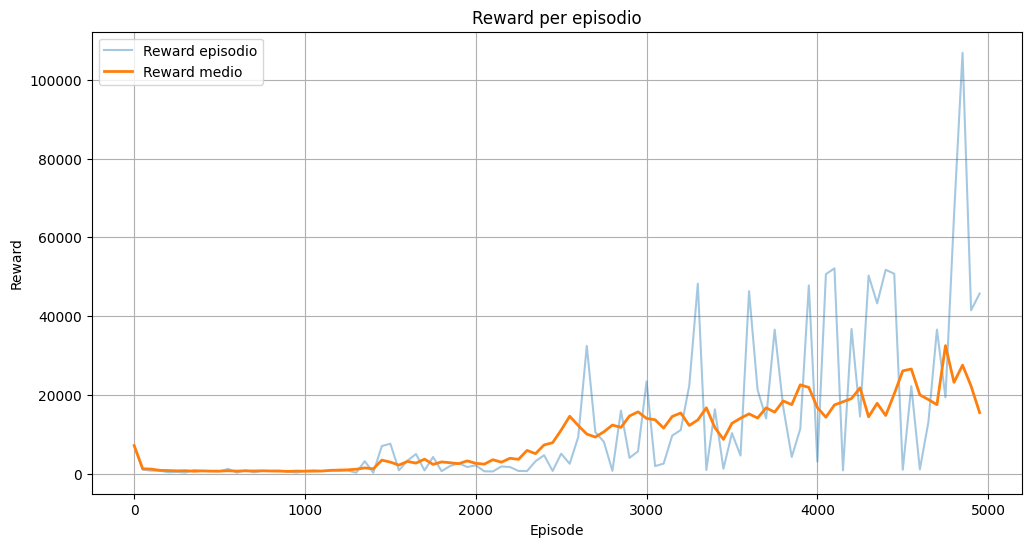

In [3]:

plt.plot(df.episode, df.reward, alpha=0.4, label="Reward episodio")
plt.plot(df.episode, df.reward_avg, linewidth=2, label="Reward medio")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.title("Reward per episodio")
plt.show()


🟦 Sopravvivenza

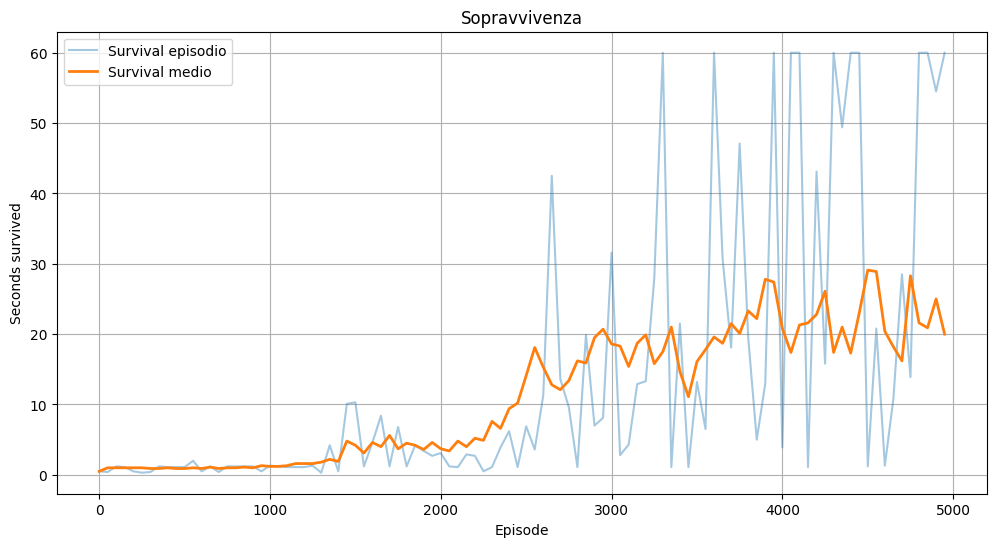

In [4]:
plt.plot(df.episode, df.survival, alpha=0.4, label="Survival episodio")
plt.plot(df.episode, df.survival_avg, linewidth=2, label="Survival medio")
plt.xlabel("Episode")
plt.ylabel("Seconds survived")
plt.legend()
plt.title("Sopravvivenza")
plt.show()


🟦 Catene causali

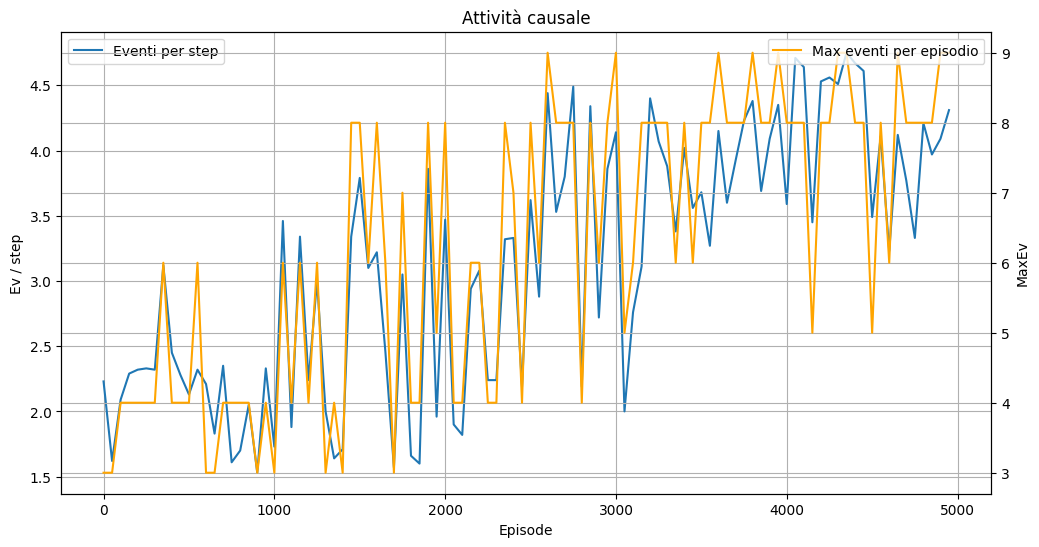

In [ ]:
fig, ax1 = plt.subplots()

ax1.plot(df.episode, df.ev_per_step, label="Eventi per step")
ax1.set_ylabel("Ev / step") # Ev/step = numero medio di attributi dello stato che cambiano “in modo significativo” per step

ax2 = ax1.twinx()
ax2.plot(df.episode, df.max_ev, color="orange", label="Max eventi per episodio")
ax2.set_ylabel("MaxEv")

ax1.set_xlabel("Episode")
ax1.set_title("Attività causale")

ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.show()


🟦  Q-values

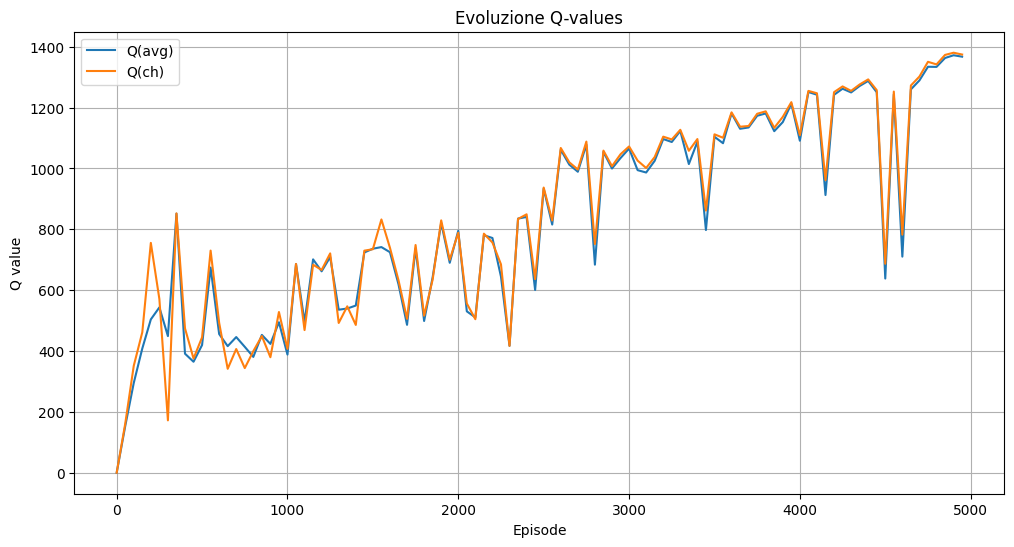

In [6]:
plt.plot(df.episode, df.q_avg, label="Q(avg)")
plt.plot(df.episode, df.q_ch, label="Q(ch)")
plt.xlabel("Episode")
plt.ylabel("Q value")
plt.legend()
plt.title("Evoluzione Q-values")
plt.show()
